# 🔍 Lab 6: KNN Classification — K-Nearest Neighbors
### DATA.110 - Introduction to Python Programming for Machine Learning
---
**Objective:** Understand the K-Nearest Neighbors algorithm, implement it from scratch, apply it using scikit-learn, tune hyperparameters, and evaluate classification performance.

**Topics Covered:**
- KNN Algorithm Theory
- KNN from Scratch
- KNN with Scikit-Learn
- Choosing the optimal K (Elbow Method)
- Classification Metrics (Accuracy, Precision, Recall, F1)
- Confusion Matrix
- Feature Scaling (critical for KNN)
- Decision Boundary Visualization
- Multi-class Classification (Iris Dataset)
- Cross-Validation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import Counter

from sklearn.datasets import load_iris, make_classification, make_blobs
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from sklearn.pipeline import Pipeline

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)
print("All libraries imported successfully.")

All libraries imported successfully.


## 1. KNN Algorithm — Intuition

**K-Nearest Neighbors (KNN)** is a simple, non-parametric, instance-based learning algorithm.

**How it works:**
1. Store all training data points
2. For a new test point, compute its **distance** to every training point
3. Select the **K nearest** neighbors
4. Classify by **majority vote** (classification) or **average** (regression)

**Common distance metrics:**
$$d_{Euclidean}(p, q) = \sqrt{\sum_{i=1}^{n}(p_i - q_i)^2}$$
$$d_{Manhattan}(p, q) = \sum_{i=1}^{n}|p_i - q_i|$$

**Key hyperparameter:** K — the number of neighbors to consider.

## 2. KNN from Scratch

In [2]:
class KNNClassifier:
    """K-Nearest Neighbors Classifier implemented from scratch."""
    
    def __init__(self, k=3, metric='euclidean'):
        self.k = k
        self.metric = metric
    
    def fit(self, X, y):
        """Store training data."""
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        return self
    
    def _distance(self, p, q):
        if self.metric == 'euclidean':
            return np.sqrt(np.sum((p - q) ** 2))
        elif self.metric == 'manhattan':
            return np.sum(np.abs(p - q))
    
    def predict_single(self, x):
        """Predict class for a single point."""
        distances = [self._distance(x, xi) for xi in self.X_train]
        k_indices = np.argsort(distances)[:self.k]
        k_labels  = self.y_train[k_indices]
        most_common = Counter(k_labels).most_common(1)[0][0]
        return most_common
    
    def predict(self, X):
        """Predict classes for multiple points."""
        return np.array([self.predict_single(x) for x in X])
    
    def score(self, X, y):
        return accuracy_score(y, self.predict(X))

print("KNNClassifier class defined.")

KNNClassifier class defined.


In [3]:
# Test on a simple 2D dataset
from sklearn.datasets import make_blobs

X_blob, y_blob = make_blobs(n_samples=150, centers=3, cluster_std=1.0,
                             n_features=2, random_state=42)

X_tr, X_te, y_tr, y_te = train_test_split(X_blob, y_blob, test_size=0.3, random_state=42)

knn_scratch = KNNClassifier(k=5)
knn_scratch.fit(X_tr, y_tr)
y_pred_scratch = knn_scratch.predict(X_te)

acc = accuracy_score(y_te, y_pred_scratch)
print(f"KNN from Scratch (k=5)")
print(f"  Accuracy on test set: {acc:.4f} ({acc*100:.1f}%)")
print(f"  Test samples: {len(y_te)}")

KNN from Scratch (k=5)
  Accuracy on test set: 1.0000 (100.0%)
  Test samples: 45


## 3. KNN with Scikit-Learn

In [4]:
# Always scale features before KNN!
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc = scaler.transform(X_te)

knn_sk = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_sk.fit(X_tr_sc, y_tr)
y_pred_sk = knn_sk.predict(X_te_sc)

print("KNN with scikit-learn (k=5, scaled):")
print(f"  Accuracy: {accuracy_score(y_te, y_pred_sk):.4f}")
print(f"  Precision (macro): {precision_score(y_te, y_pred_sk, average='macro'):.4f}")
print(f"  Recall (macro):    {recall_score(y_te, y_pred_sk, average='macro'):.4f}")
print(f"  F1 Score (macro):  {f1_score(y_te, y_pred_sk, average='macro'):.4f}")

KNN with scikit-learn (k=5, scaled):
  Accuracy: 1.0000
  Precision (macro): 1.0000
  Recall (macro):    1.0000
  F1 Score (macro):  1.0000


## 4. Choosing the Optimal K — Elbow Method

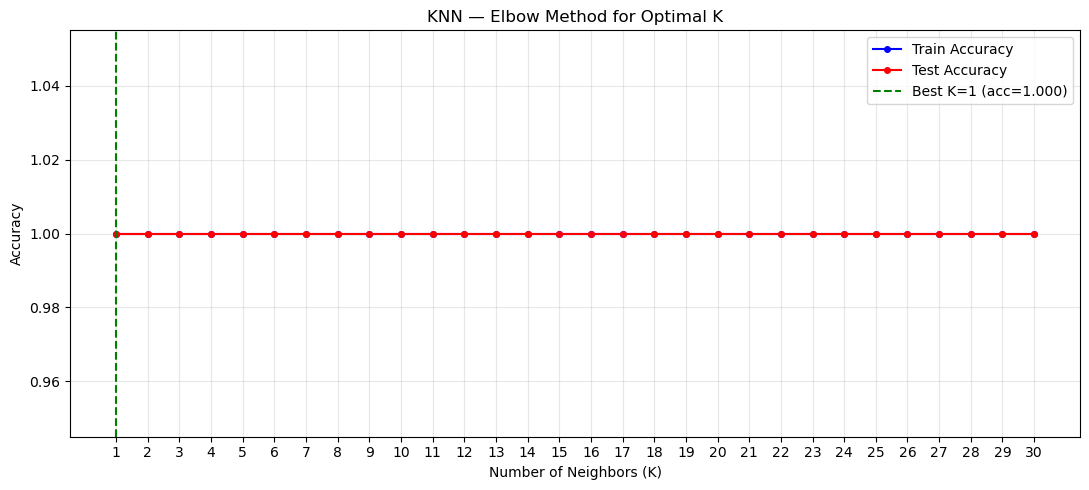

Best K: 1  |  Best Test Accuracy: 1.0000


In [5]:
k_range = range(1, 31)
train_accs, test_accs = [], []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_tr_sc, y_tr)
    train_accs.append(knn.score(X_tr_sc, y_tr))
    test_accs.append(knn.score(X_te_sc, y_te))

best_k = k_range[np.argmax(test_accs)]
best_acc = max(test_accs)

plt.figure(figsize=(11, 5))
plt.plot(k_range, train_accs, 'b-o', markersize=4, label='Train Accuracy')
plt.plot(k_range, test_accs,  'r-o', markersize=4, label='Test Accuracy')
plt.axvline(best_k, color='green', linestyle='--', label=f'Best K={best_k} (acc={best_acc:.3f})')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.title('KNN — Elbow Method for Optimal K')
plt.xticks(k_range)
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print(f"Best K: {best_k}  |  Best Test Accuracy: {best_acc:.4f}")

## 5. Decision Boundary Visualization

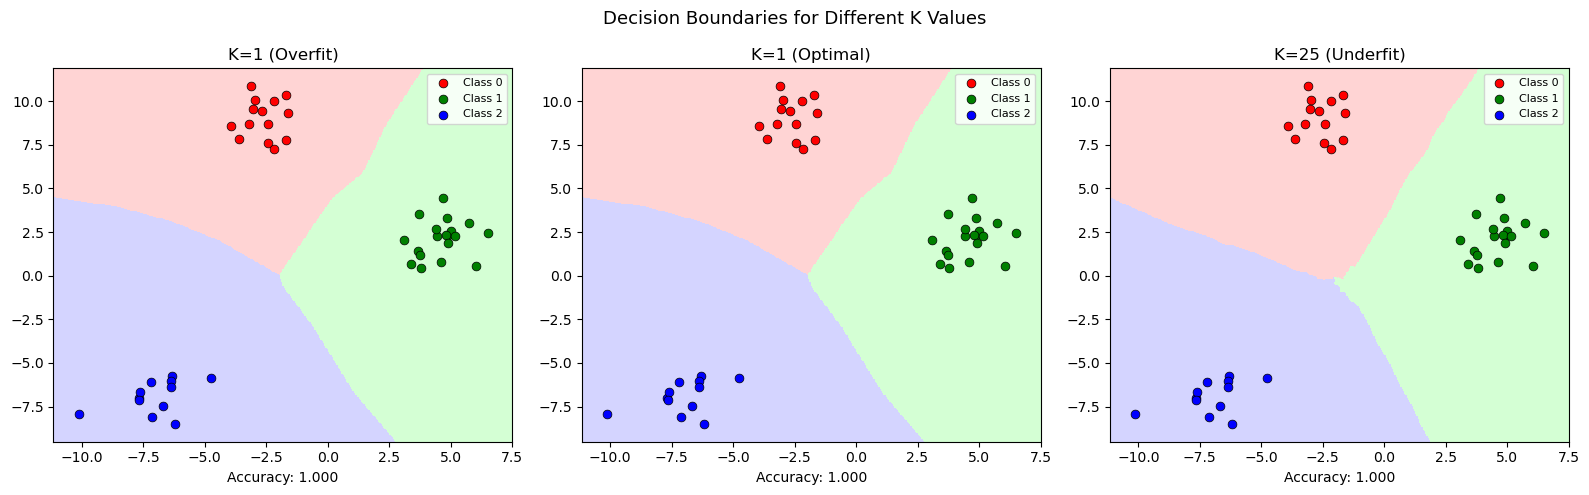

In [6]:
def plot_decision_boundary(X, y, model, ax, title, scaler=None):
    """Plot decision boundary for a 2D classifier."""
    h = 0.05
    x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
    y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]
    if scaler:
        grid = scaler.transform(grid)
    Z = model.predict(grid).reshape(xx.shape)
    
    cmap_light = mcolors.ListedColormap(['#FFAAAA','#AAFFAA','#AAAAFF'])
    cmap_bold  = ['red', 'green', 'blue']
    
    ax.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='auto', alpha=0.5)
    for cls, color in zip(np.unique(y), cmap_bold):
        mask = y == cls
        ax.scatter(X[mask, 0], X[mask, 1], c=color, s=40,
                   edgecolors='k', linewidth=0.5, label=f'Class {cls}')
    ax.set_title(title); ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, k, title in zip(axes, [1, best_k, 25],
                         [f'K=1 (Overfit)', f'K={best_k} (Optimal)', 'K=25 (Underfit)']):
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_tr_sc, y_tr)
    plot_decision_boundary(X_te, y_te, m, ax, title, scaler)
    acc = m.score(X_te_sc, y_te)
    ax.set_xlabel(f'Accuracy: {acc:.3f}')

plt.suptitle('Decision Boundaries for Different K Values', fontsize=13)
plt.tight_layout(); plt.show()

## 6. Confusion Matrix and Classification Report

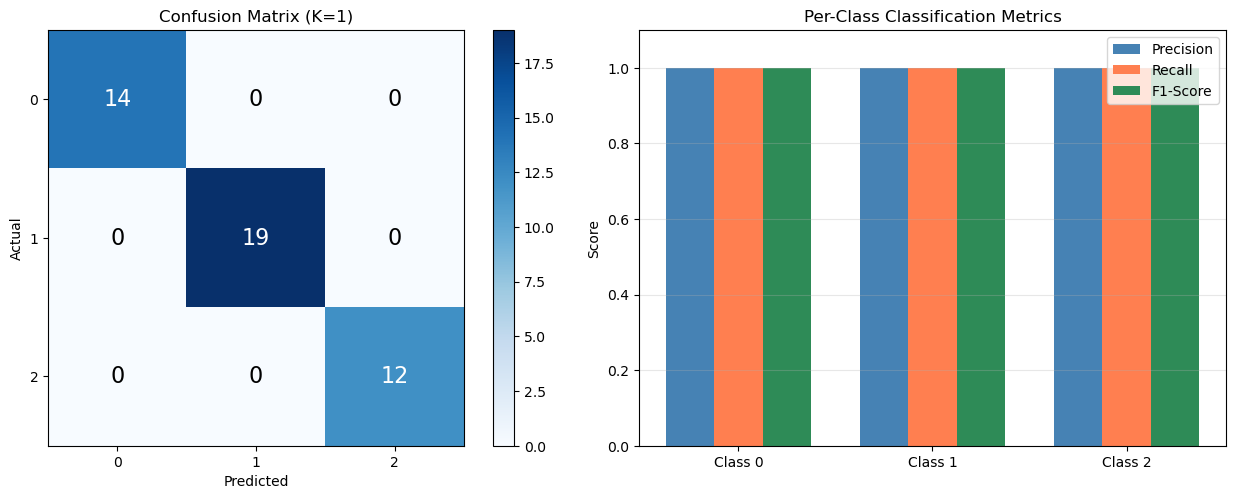

Full Classification Report:
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        14
     Class 1       1.00      1.00      1.00        19
     Class 2       1.00      1.00      1.00        12

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [7]:
# Best model
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_tr_sc, y_tr)
y_pred_best = knn_best.predict(X_te_sc)

# Confusion matrix
cm = confusion_matrix(y_te, y_pred_best)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot confusion matrix
im = axes[0].imshow(cm, cmap='Blues')
plt.colorbar(im, ax=axes[0])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[0].text(j, i, str(cm[i,j]), ha='center', va='center',
                     fontsize=16, color='white' if cm[i,j] > cm.max()/2 else 'black')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title(f'Confusion Matrix (K={best_k})')
axes[0].set_xticks(range(cm.shape[1])); axes[0].set_yticks(range(cm.shape[0]))

# Metrics bar chart
classes = np.unique(y_te)
prec = precision_score(y_te, y_pred_best, average=None)
rec  = recall_score(y_te,    y_pred_best, average=None)
f1   = f1_score(y_te,        y_pred_best, average=None)

x = np.arange(len(classes))
width = 0.25
axes[1].bar(x - width, prec, width, label='Precision', color='steelblue')
axes[1].bar(x,          rec,  width, label='Recall',    color='coral')
axes[1].bar(x + width, f1,   width, label='F1-Score',  color='seagreen')
axes[1].set_xticks(x); axes[1].set_xticklabels([f'Class {c}' for c in classes])
axes[1].set_ylim(0, 1.1); axes[1].set_ylabel('Score')
axes[1].set_title('Per-Class Classification Metrics')
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

print("Full Classification Report:")
print(classification_report(y_te, y_pred_best, 
                             target_names=[f'Class {c}' for c in classes]))

## 7. Real Dataset — Iris Classification

In [8]:
# Load Iris dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
feature_names = iris.feature_names
target_names  = iris.target_names

iris_df = pd.DataFrame(X_iris, columns=feature_names)
iris_df['Species'] = [target_names[i] for i in y_iris]

print("Iris Dataset:")
print(f"  Shape: {X_iris.shape}")
print(f"  Features: {feature_names}")
print(f"  Classes: {target_names}")
print(f"  Class distribution: {dict(zip(*np.unique(y_iris, return_counts=True)))}")
print()
print(iris_df.head(10))

Iris Dataset:
  Shape: (150, 4)
  Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
  Classes: ['setosa' 'versicolor' 'virginica']
  Class distribution: {np.int64(0): np.int64(50), np.int64(1): np.int64(50), np.int64(2): np.int64(50)}

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8         

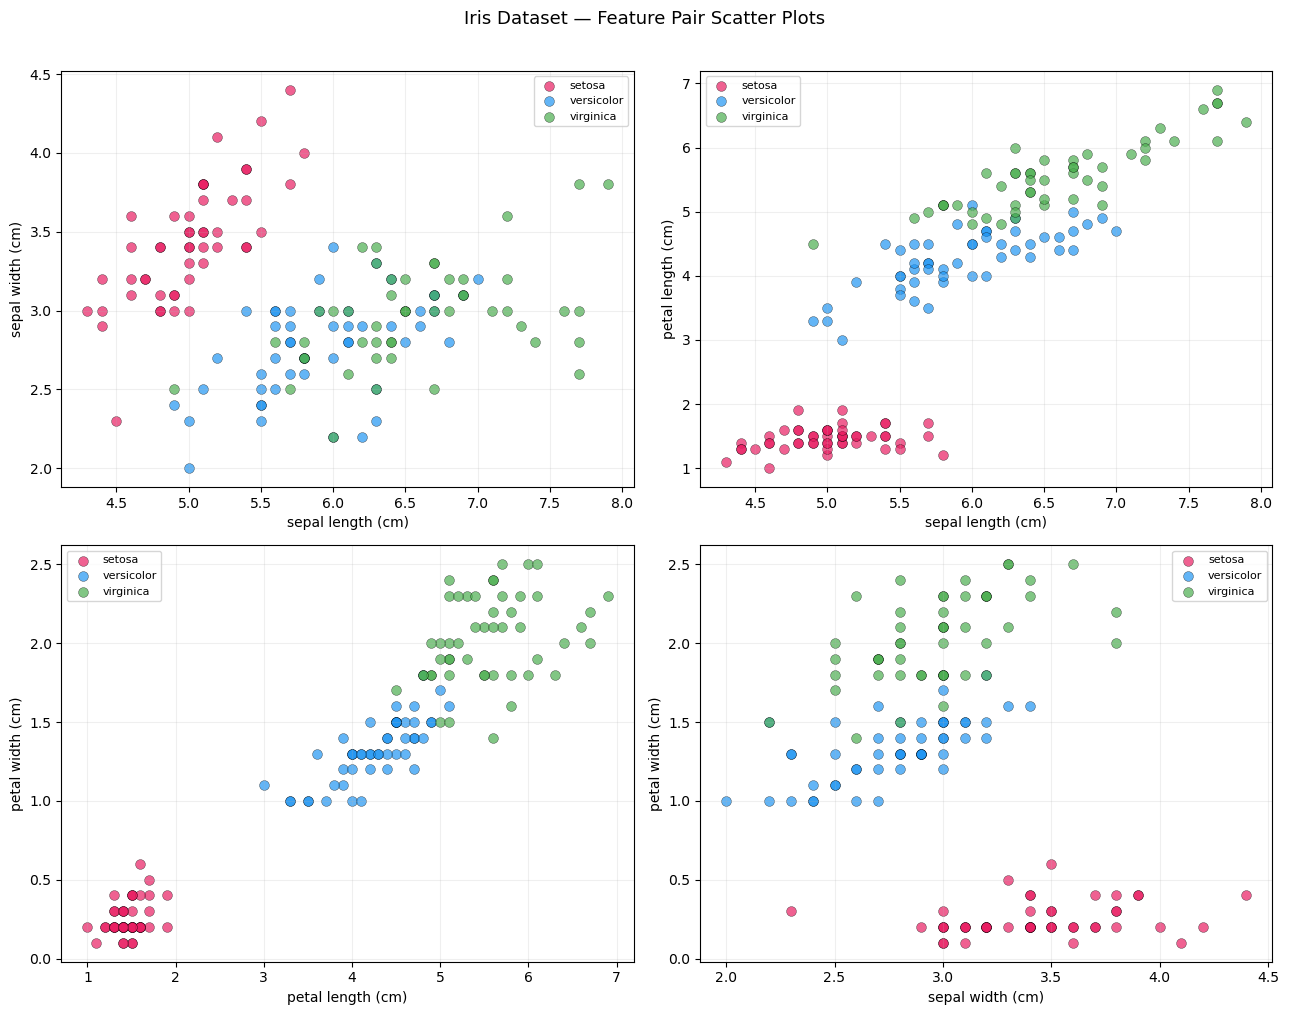

In [9]:
# Exploratory analysis
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
colors = ['#E91E63', '#2196F3', '#4CAF50']

feature_pairs = [
    (0, 1, 'sepal length (cm)', 'sepal width (cm)'),
    (0, 2, 'sepal length (cm)', 'petal length (cm)'),
    (2, 3, 'petal length (cm)', 'petal width (cm)'),
    (1, 3, 'sepal width (cm)',  'petal width (cm)')
]

for ax, (xi, yi, xlab, ylab) in zip(axes.flat, feature_pairs):
    for cls, color, name in zip(range(3), colors, target_names):
        mask = y_iris == cls
        ax.scatter(X_iris[mask, xi], X_iris[mask, yi],
                   c=color, s=50, alpha=0.7, label=name, edgecolors='k', linewidth=0.3)
    ax.set_xlabel(xlab); ax.set_ylabel(ylab)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.2)

plt.suptitle('Iris Dataset — Feature Pair Scatter Plots', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

In [10]:
# KNN on Iris — Pipeline with scaling
X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(
    X_iris, y_iris, test_size=0.25, random_state=42, stratify=y_iris)

# Grid search for best K and distance metric
param_grid = {
    'knn__n_neighbors': [1,3,5,7,9,11,13,15],
    'knn__metric':      ['euclidean','manhattan','minkowski'],
    'knn__weights':     ['uniform','distance']
}

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn',    KNeighborsClassifier())
])

gs = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
gs.fit(X_tr_i, y_tr_i)

print("Grid Search Results:")
print(f"  Best params:   {gs.best_params_}")
print(f"  Best CV score: {gs.best_score_:.4f}")

# Evaluate best model on test set
y_pred_iris = gs.predict(X_te_i)
print(f"\nTest Set Accuracy: {accuracy_score(y_te_i, y_pred_iris):.4f}")
print()
print(classification_report(y_te_i, y_pred_iris, target_names=target_names))

Grid Search Results:
  Best params:   {'knn__metric': 'euclidean', 'knn__n_neighbors': 7, 'knn__weights': 'uniform'}
  Best CV score: 0.9549

Test Set Accuracy: 0.9474

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.87      1.00      0.93        13
   virginica       1.00      0.85      0.92        13

    accuracy                           0.95        38
   macro avg       0.96      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38



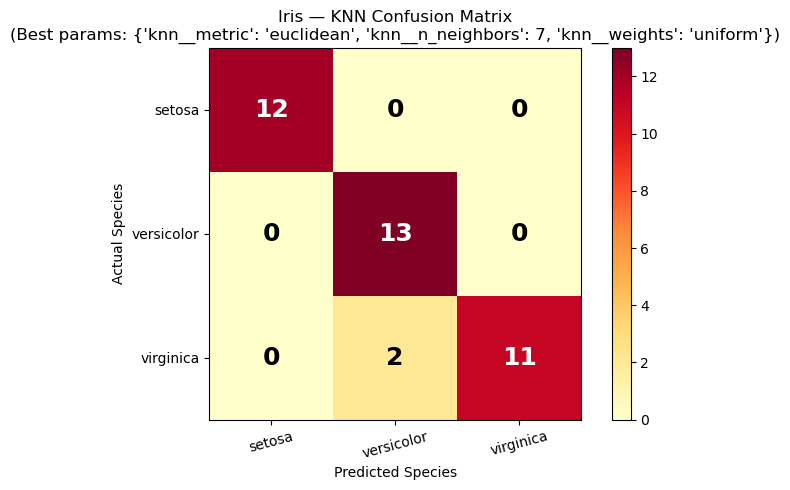

In [11]:
# Confusion matrix for Iris
cm_iris = confusion_matrix(y_te_i, y_pred_iris)

plt.figure(figsize=(7, 5))
im = plt.imshow(cm_iris, cmap='YlOrRd', interpolation='nearest')
plt.colorbar(im)

for i in range(3):
    for j in range(3):
        plt.text(j, i, str(cm_iris[i, j]), ha='center', va='center',
                 fontsize=18, fontweight='bold',
                 color='white' if cm_iris[i,j] > cm_iris.max()/2 else 'black')

plt.xticks(range(3), target_names, rotation=15)
plt.yticks(range(3), target_names)
plt.xlabel('Predicted Species'); plt.ylabel('Actual Species')
plt.title(f'Iris — KNN Confusion Matrix\n(Best params: {gs.best_params_})')
plt.tight_layout(); plt.show()

## 8. Effect of Feature Scaling on KNN

Accuracy — Effect of Feature Scaling:
   Without Scaling  With Scaling
K                               
3           0.9737        0.9211
5           0.9737        0.9211
7           0.9474        0.9474
9           0.9737        0.9737


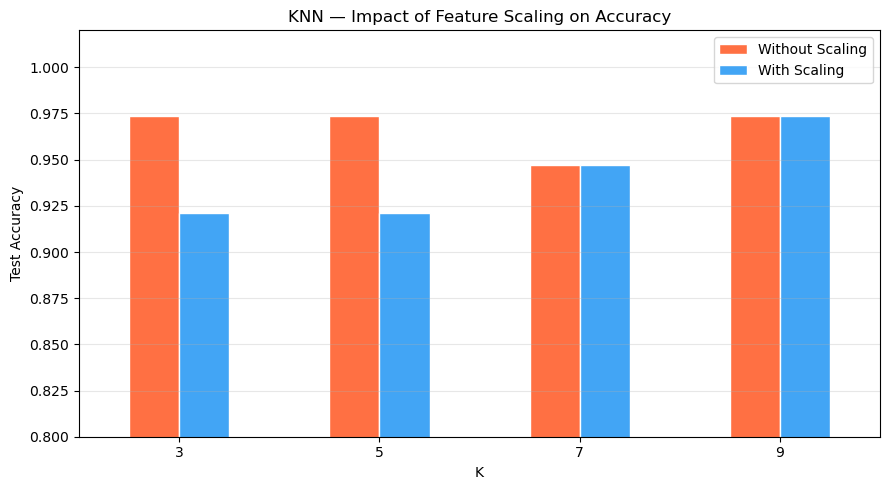

In [12]:
# Compare with and without scaling
results_scaling = []

for k in [3, 5, 7, 9]:
    # Without scaling
    knn_raw = KNeighborsClassifier(n_neighbors=k)
    knn_raw.fit(X_tr_i, y_tr_i)
    acc_raw = knn_raw.score(X_te_i, y_te_i)
    
    # With scaling
    pipe_k = Pipeline([('sc',StandardScaler()),('knn',KNeighborsClassifier(n_neighbors=k))])
    pipe_k.fit(X_tr_i, y_tr_i)
    acc_sc = pipe_k.score(X_te_i, y_te_i)
    
    results_scaling.append({'K':k, 'Without Scaling':acc_raw, 'With Scaling':acc_sc})

df_scale = pd.DataFrame(results_scaling).set_index('K')
print("Accuracy — Effect of Feature Scaling:")
print(df_scale.round(4))

ax = df_scale.plot(kind='bar', figsize=(9, 5), rot=0, 
                   color=['#FF7043','#42A5F5'], edgecolor='white')
ax.set_xlabel('K')
ax.set_ylabel('Test Accuracy')
ax.set_title('KNN — Impact of Feature Scaling on Accuracy')
ax.set_ylim(0.8, 1.02)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

## 9. Cross-Validation Summary

In [13]:
best_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(**{k.replace('knn__',''):v 
                                    for k,v in gs.best_params_.items()}))
])

cv_scores = cross_val_score(best_pipe, X_iris, y_iris, cv=10, scoring='accuracy')

print("10-Fold Cross-Validation (Best KNN on Iris):")
for i, sc in enumerate(cv_scores, 1):
    bar = '█' * int(sc * 30)
    print(f"  Fold {i:>2}: {sc:.4f}  {bar}")
print(f"\n  Mean Accuracy:   {cv_scores.mean():.4f}")
print(f"  Std Deviation:   {cv_scores.std():.4f}")
print(f"  95% CI:          [{cv_scores.mean()-2*cv_scores.std():.4f}, {cv_scores.mean()+2*cv_scores.std():.4f}]")

10-Fold Cross-Validation (Best KNN on Iris):
  Fold  1: 1.0000  ██████████████████████████████
  Fold  2: 0.9333  ████████████████████████████
  Fold  3: 1.0000  ██████████████████████████████
  Fold  4: 0.9333  ████████████████████████████
  Fold  5: 0.9333  ████████████████████████████
  Fold  6: 0.9333  ████████████████████████████
  Fold  7: 0.8667  ██████████████████████████
  Fold  8: 0.9333  ████████████████████████████
  Fold  9: 1.0000  ██████████████████████████████
  Fold 10: 1.0000  ██████████████████████████████

  Mean Accuracy:   0.9533
  Std Deviation:   0.0427
  95% CI:          [0.8680, 1.0387]


## 10. KNN Advantages, Disadvantages, and Best Practices

In [14]:
summary = """
╔══════════════════════════════════════════════════════════════╗
║            KNN — Summary and Best Practices                 ║
╠══════════════════════════════════════════════════════════════╣
║  ✅ ADVANTAGES                                               ║
║    • Simple to understand and implement                     ║
║    • No training phase (lazy learner)                       ║
║    • Naturally handles multi-class problems                 ║
║    • Non-parametric (no assumption about data distribution) ║
╠══════════════════════════════════════════════════════════════╣
║  ❌ DISADVANTAGES                                            ║
║    • Slow prediction for large datasets (O(n×d))            ║
║    • Sensitive to irrelevant features                       ║
║    • Sensitive to feature scale (MUST standardize!)         ║
║    • High memory usage (stores all training data)           ║
╠══════════════════════════════════════════════════════════════╣
║  💡 BEST PRACTICES                                           ║
║    • Always scale features (StandardScaler or MinMaxScaler) ║
║    • Use odd K for binary classification (avoid ties)       ║
║    • Try different distance metrics (Euclidean, Manhattan)  ║
║    • Use cross-validation to select optimal K               ║
║    • Remove irrelevant / redundant features first           ║
╚══════════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════════╗
║            KNN — Summary and Best Practices                 ║
╠══════════════════════════════════════════════════════════════╣
║  ✅ ADVANTAGES                                               ║
║    • Simple to understand and implement                     ║
║    • No training phase (lazy learner)                       ║
║    • Naturally handles multi-class problems                 ║
║    • Non-parametric (no assumption about data distribution) ║
╠══════════════════════════════════════════════════════════════╣
║  ❌ DISADVANTAGES                                            ║
║    • Slow prediction for large datasets (O(n×d))            ║
║    • Sensitive to irrelevant features                       ║
║    • Sensitive to feature scale (MUST standardize!)         ║
║    • High memory usage (stores all training data)           ║
╠══════════════════════════════════════════════════════════════╣
║  💡 BEST PRACTICES                

## Summary

| Concept | Key Point |
|---|---|
| **Algorithm** | Vote from K nearest neighbors by distance |
| **Distance** | Euclidean (most common), Manhattan, Minkowski |
| **K** | Small K → complex boundary (overfit); Large K → smooth (underfit) |
| **Scaling** | **Critical** — always scale before KNN |
| **Accuracy** | Correct / Total predictions |
| **Precision** | True Positive / (TP + FP) — avoid false alarms |
| **Recall** | True Positive / (TP + FN) — avoid missing positives |
| **F1 Score** | Harmonic mean of Precision & Recall |
| **Confusion Matrix** | Full breakdown of prediction errors |

---
✅ **Lab 6 Complete — All 6 Labs Finished!**